ordering.txt trovato: uso la mappatura esatta.


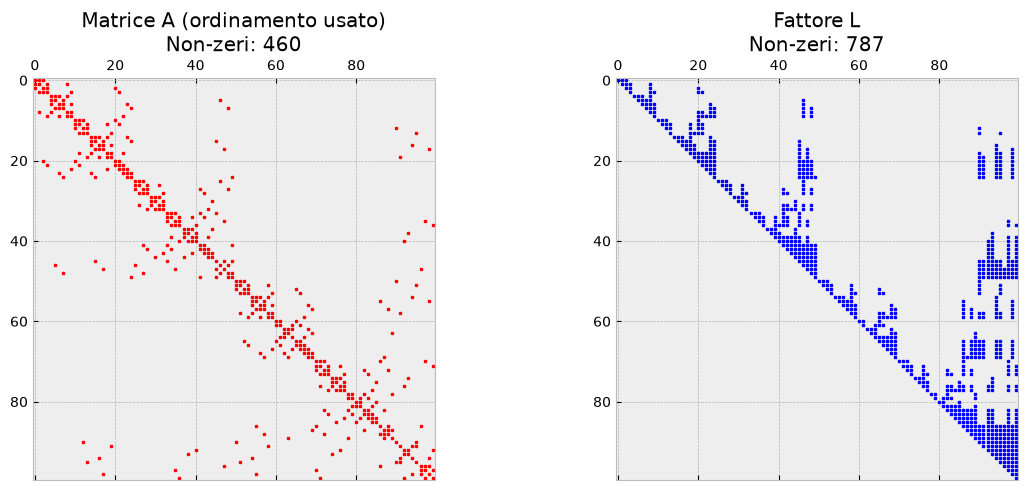

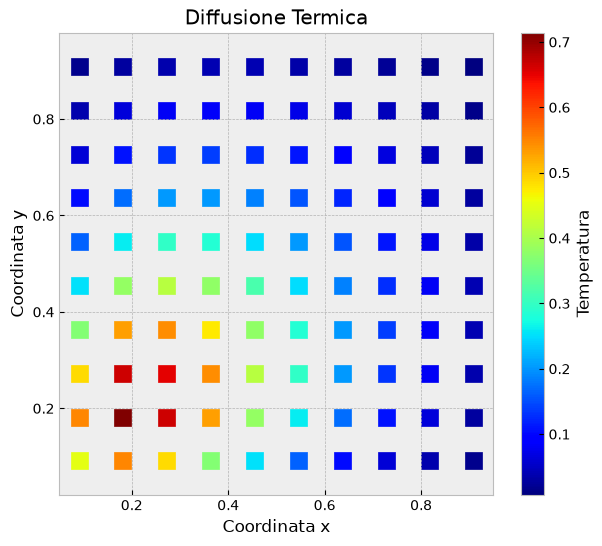

u min=0.0074, u max=0.7142 (deve essere vicino all'origine (0,0), dove f e' massima)


In [1]:
 
# Task 4 - Fattorizzazione di Cholesky e visualizzazione della soluzione

# NOTA IMPORTANTE SULL'ORDINAMENTO
# A.txt e rhs.txt sono espressi nell'ordinamento "nuovo" (nested dissection), per scelta nel task 5 lì vedrò tutti e 2.
# mentre coords.txt è nell'ordinamento "naturale" prodotto dal Task 1.
# Per sapere a quale nodo geometrico (x, y) corrisponde ciascuna riga/colonna
# di A.txt serve il file ordering.txt (righe: m n) generato dal Task 2, dove
# m è l'indice nuovo e n l'indice originale in coords.txt.
# Metodo primario: carichiamo ordering.txt (funzione load_ordering_file).
# Verificato sui tuoi file: la corrispondenza è esatta (errore residuo
# ~1e-7, solo arrotondamento del testo).
# Cosa extra:
# Fallback (usato solo se ordering.txt manca): ricostruiamo la mappatura
# sfruttando rhs[i] = f(x_i, y_i) = exp(-10*(x^2+y^2)), iniettiva sulla
# griglia. Funziona SOLO se u0 = 0; se in futuro usi u0 != 0 questa
# scorciatoia non e' piu' valida e serve ordering.txt.
 

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from sksparse.cholmod import cho_factor

plt.style.use('bmh')

# --- 1. CARICAMENTO DATI 
A_data = np.loadtxt('A.txt')
rhs = np.loadtxt('rhs.txt')
coords = np.loadtxt('coords.txt')

righe = A_data[:, 0].astype(int)
colonne = A_data[:, 1].astype(int)
valori = A_data[:, 2]
N_nodi = len(rhs)
N = int(np.sqrt(N_nodi))

A_csc = sp.csc_matrix((valori, (righe, colonne)), shape=(N_nodi, N_nodi))


def load_ordering_file(path, coords):
    # Se hai ordering.txt (righe: m n), usa questa funzione al posto del
    # matching euristico. Ritorna x_new, y_new nell'ordinamento di A/rhs.
    ordering = np.loadtxt(path, dtype=int)      # colonne: m (nuovo), n (coords.txt)
    m = ordering[:, 0]
    n = ordering[:, 1]
    order_map = np.empty(len(m), dtype=int)
    order_map[m] = n                             # order_map[nuovo_indice] = indice_naturale
    idx_coords = coords[:, 0].astype(int)
    # coords potrebbe non essere gia' ordinato per indice n, quindi mappiamo con cura
    pos_of_n = np.empty(idx_coords.max() + 1, dtype=int)
    pos_of_n[idx_coords] = np.arange(len(idx_coords))
    riga_naturale = pos_of_n[order_map]
    x_new = coords[riga_naturale, 3]
    y_new = coords[riga_naturale, 4]
    return x_new, y_new


def reconstruct_ordering_from_rhs(rhs, coords):
    # Fallback usato quando ordering.txt non e' disponibile: sfrutta
    # l'iniettivita' di f(x,y) = exp(-10*(x^2+y^2)) per recuperare la
    # corrispondenza fra indice nuovo (di A/rhs) e indice naturale.
    x = coords[:, 3]
    y = coords[:, 4]
    f_nat = np.exp(-10 * (x**2 + y**2))

    nat_sorted_idx = np.argsort(f_nat)
    rhs_sorted_idx = np.argsort(rhs)

    order_map = np.empty(len(rhs), dtype=int)   # order_map[nuovo_indice] = indice_naturale
    order_map[rhs_sorted_idx] = nat_sorted_idx

    # controllo di qualita' del matching
    err = np.max(np.abs(rhs - f_nat[order_map]))
    if err > 1e-3:
        raise RuntimeError(
            f"Matching rhs<->coords fallito (errore max {err:.3e}). "
            "Molto probabilmente stai usando u0 != 0: in quel caso serve "
            "ordering.txt, il matching euristico non e' valido."
        )
    return x[order_map], y[order_map]


try:
    x_new, y_new = load_ordering_file('ordering.txt', coords)
    print("ordering.txt trovato: uso la mappatura esatta.")
except OSError:
    print("ordering.txt non trovato: ricostruisco la mappatura da rhs.txt "
          "(valido solo se u0 = 0).")
    x_new, y_new = reconstruct_ordering_from_rhs(rhs, coords)

# --- 2. FATTORIZZAZIONE DI CHOLESKY 
# A è già simmetrica definita positiva (diagonale 4*k/h^2, extra-diag
# -k/h^2), quindi si fattorizza direttamente A (non serve cambiare segno).
# order="natural" dice a CHOLMOD di NON riordinare ulteriormente: così
# il fill-in che osserviamo riflette esattamente il riordinamento (nested
# dissection) che avete implementato nel Task 2.
#
# NOTA: in questa versione di scikit-sparse (0.5.0, API rinnovata rispetto a quella "storica" descritta nel testo del progetto) è cho_factor() a restituire l'oggetto CholeskyFactor con i metodi .solve()/.get_factor().
# La funzione cholesky() in questa versione restituisce invece le matrici
# direttamente (una tupla) e NON è quella che serve qui.
fattore = cho_factor(A_csc, order="natural")   # oggetto CholeskyFactor
L_mat = sp.csc_matrix(fattore.get_factor())     # con order="natural" P = identita'
u_new = fattore.solve(rhs)                      # soluzione nell'ordinamento di A/rhs

# --- 3. VISUALIZZAZIONE 

# Sparsita' / fill-in
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.spy(A_csc, markersize=1.5, color='red')
ax1.set_title(f"Matrice A (ordinamento usato)\nNon-zeri: {A_csc.nnz}")
ax2.spy(L_mat, markersize=1.5, color='blue')
ax2.set_title(f"Fattore L\nNon-zeri: {L_mat.nnz}")
plt.tight_layout()
plt.savefig('sparsity.png', dpi=150)
plt.show()

# Mappa di temperatura, usando le coordinate ricostruite/lette correttamente
plt.figure(figsize=(7, 6))
grafico = plt.scatter(x_new, y_new, c=u_new, cmap='jet', s=150, marker='s')
plt.colorbar(grafico, label="Temperatura")
plt.title("Diffusione Termica")
plt.xlabel("Coordinata x")
plt.ylabel("Coordinata y")
plt.axis('equal')
plt.savefig('heatmap.png', dpi=150)
plt.show()

print(f"u min={u_new.min():.4f}, u max={u_new.max():.4f} (deve essere vicino "
      "all'origine (0,0), dove f e' massima)")